In [1]:
# --- parameters (injected by build_notebooks.py) ---
COMPETITION = 'titanic'
COMP_DIR = '/Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster'
RUN_DIR = '/Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster/kaggle_run'
CONFIG_PATH = '/Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster/config.yaml'
TRAIN_CSV = '/Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster/data/train_fe.csv'
TEST_CSV = '/Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster/data/test_fe.csv'
TARGET = 'Survived'
ID_COL = 'PassengerId'
METRIC = 'accuracy'
RANDOM_STATE = 42
HOLDOUT_FRACTION = 0.2
MLFLOW_URI = 'sqlite:////Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster/kaggle_run/mlflow.db'
MLFLOW_DB = '/Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster/kaggle_run/mlflow.db'

# 🏆 Champion model — titanic

**Run:** `20260713-0916`  ·  generated by the `kaggle-ml-loop` skill

The pipeline ran an adaptive multi-loop search (EDA → feature-engineering agents →
baseline training → Optuna → ensembling → knowledge distillation) and picked a single
champion on an untouched holdout. This notebook explains **what the experiments taught**
and **how the champion reads the data**.

### Links
| What | Where |
|---|---|
| Champion provenance | [`../kaggle_run/champion/champion.json`](../kaggle_run/champion/champion.json) |
| Champion model | [`../kaggle_run/champion/model.joblib`](../kaggle_run/champion/model.joblib) |
| Submission CSV | [`../kaggle_run/champion/submission.csv`](../kaggle_run/champion/submission.csv) |
| Run config | [`../config.yaml`](../config.yaml) |
| Cross-loop knowledge | [`../kaggle_run/knowledge.md`](../kaggle_run/knowledge.md) |
| Run directory | [`../kaggle_run`](../kaggle_run) |

### MLflow experiment tracking
```bash
mlflow ui --backend-store-uri sqlite:////Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster/kaggle_run/mlflow.db
```
Open **http://127.0.0.1:5000** — every model, Optuna trial, and ensemble for this run is
logged there under experiments `titanic/loop_<N>` and `titanic/final`.


In [2]:
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
PALETTE = "flare"
sns.set_palette(sns.color_palette(PALETTE, 8))
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

RUN = Path(RUN_DIR)
champ = json.loads((RUN / "champion" / "champion.json").read_text())
print("Champion:", champ.get("kind"), "from loop", champ.get("loop"))
champ

Champion: model from loop 2


{'metric': 'accuracy',
 'loop': 2,
 'kind': 'model',
 'detail': {'pair': 'target_encoded__hist_gbm__optuna',
  'variant': 'target_encoded',
  'model': 'hist_gbm',
  'stage': 'optimized',
  'cv_mean': 0.8385206342952822,
  'cv_std': 0.03332127958639286,
  'params': {'learning_rate': 0.09519754482692679,
   'max_iter': 318,
   'max_leaf_nodes': 73,
   'min_samples_leaf': 35,
   'l2_regularization': 4.609885087947832e-07}},
 'cv_mean_dev': 0.8385206342952822,
 'holdout_score': 0.81564,
 'finalists': [{'candidate': 'loop2/target_encoded__hist_gbm__optuna',
   'cv_mean': 0.8385206342952822,
   'holdout': 0.81564},
  {'candidate': 'loop4/voting',
   'cv_mean': 0.8371121835910568,
   'holdout': 0.81006},
  {'candidate': 'loop4/power_poly_kbest__hist_gbm__optuna',
   'cv_mean': 0.8399389343051314,
   'holdout': 0.80447},
  {'candidate': 'loop3/kbest_interactions__extra_trees__optuna',
   'cv_mean': 0.8441445878065595,
   'holdout': 0.79888},
  {'candidate': 'loop4/power_poly_kbest__hist_gbm',


## 1 · Executive summary

In [3]:
detail = champ.get("detail", {})
name = detail.get("variant") or detail.get("method") or champ.get("kind")
model = detail.get("model") or detail.get("method") or "-"
print(f"Metric            : {champ.get('metric')}")
print(f"Champion kind     : {champ.get('kind')}  ({name} / {model})")
print(f"Winning loop      : {champ.get('loop')}")
print(f"CV score (dev)    : {champ.get('cv_mean_dev'):.5f}")
print(f"Holdout score     : {champ.get('holdout_score'):.5f}")
print(f"Refit on          : {champ.get('refit_on')}")
print(f"Public LB score   : <fill in after submitting — see SUBMISSIONS.md>")

Metric            : accuracy
Champion kind     : model  (target_encoded / hist_gbm)
Winning loop      : 2
CV score (dev)    : 0.83852
Holdout score     : 0.81564
Refit on          : entire training set (891 rows: 712 dev + 179 holdout)
Public LB score   : <fill in after submitting — see SUBMISSIONS.md>


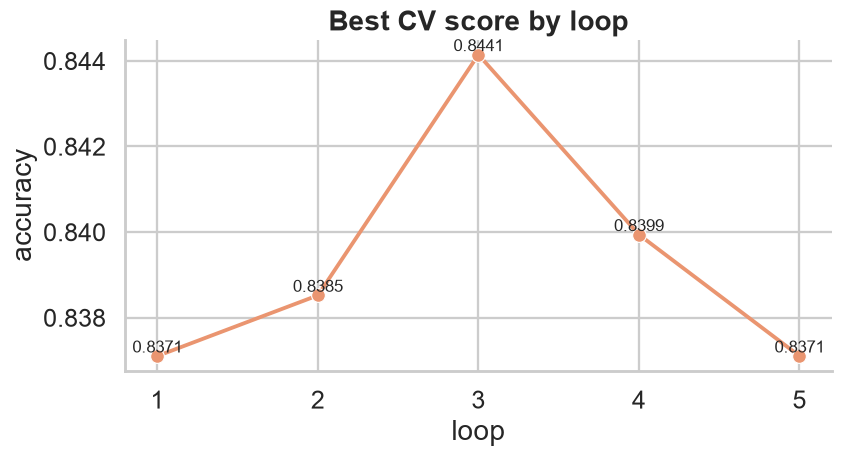

In [4]:
# Score trajectory across loops — did knowledge distillation compound?
traj = champ.get("score_trajectory_by_loop", {})
if traj:
    loops = [int(k) for k in traj.keys()]
    scores = [traj[str(k)] if str(k) in traj else traj[k] for k in traj.keys()]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.lineplot(x=list(map(int, traj.keys())), y=list(traj.values()),
                 marker="o", ax=ax, lw=2.5)
    for x, y in zip(map(int, traj.keys()), traj.values()):
        ax.text(x, y, f"{y:.4f}", ha="center", va="bottom", fontsize=11)
    ax.set_title("Best CV score by loop"); ax.set_xlabel("loop"); ax.set_ylabel(champ.get("metric"))
    ax.set_xticks(list(map(int, traj.keys())))
    sns.despine(); plt.tight_layout(); plt.show()
else:
    print("No trajectory recorded (single-loop run).")

## 2 · What the MLflow experiments taught

Pulled straight from the tracking DB via `mlflow.search_runs`, so this matches exactly
what you'd browse in the MLflow UI.

In [5]:
import mlflow
mlflow.set_tracking_uri(MLFLOW_URI)
exp = [e for e in mlflow.search_experiments() if e.name.startswith(COMPETITION + "/")]
runs = mlflow.search_runs(experiment_ids=[e.experiment_id for e in exp],
                          order_by=["metrics.cv_mean DESC"], max_results=1000)
print(f"{len(runs)} runs across {len(exp)} experiments.")
keep = [c for c in ["tags.loop","tags.variant","tags.model_family","tags.stage",
                    "metrics.cv_mean","metrics.cv_std","metrics.holdout_score"]
        if c in runs.columns]
board = runs[keep].dropna(subset=["metrics.cv_mean"]).copy()
board.columns = [c.replace("tags.","").replace("metrics.","") for c in board.columns]
board.sort_values("cv_mean", ascending=False).head(15).reset_index(drop=True)

88 runs across 6 experiments.


,loop,variant,model_family,stage,cv_mean,cv_std,holdout_score
0,3,kbest_interactions,extra_trees,optimized,0.844145,0.024128,NaN
1,4,power_poly_kbest,hist_gbm,optimized,0.839939,0.019089,NaN
2,4,power_poly_kbest,hist_gbm,baseline,0.838550,0.022576,NaN
3,2,target_encoded,hist_gbm,optimized,0.838521,0.033321,NaN
4,5,minimal,random_forest,optimized,0.837102,0.017184,NaN
5,5,minimal,hist_gbm,optimized,0.837102,0.019903,NaN
6,4,minimal,random_forest,optimized,0.837102,0.017184,NaN
7,4,minimal,hist_gbm,optimized,0.837102,0.019903,NaN
8,3,minimal,random_forest,optimized,0.837102,0.017184,NaN
9,3,minimal,hist_gbm,optimized,0.837102,0.019903,NaN


Best cv_mean by loop:
 loop
1    0.837102
2    0.838521
3    0.844145
4    0.839939
5    0.837102
Name: cv_mean, dtype: float64 



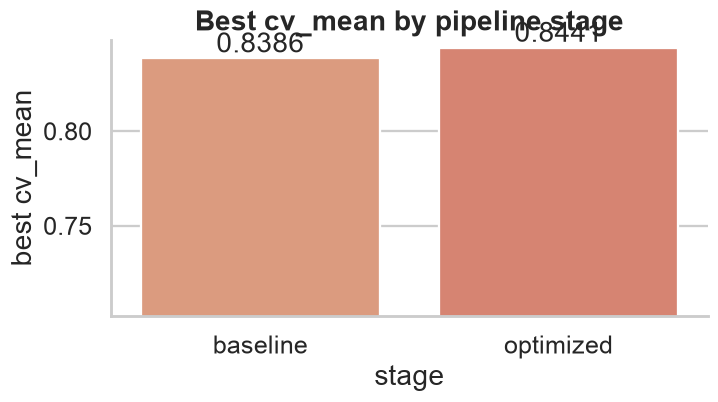

In [6]:
# Best score per loop, and baseline vs optimized vs ensemble
if "loop" in board.columns:
    best_by_loop = board.groupby("loop")["cv_mean"].max().sort_index()
    print("Best cv_mean by loop:\n", best_by_loop, "\n")
if "stage" in board.columns:
    by_stage = board.groupby("stage")["cv_mean"].agg(["max","mean","count"])
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(x=by_stage.index, y=by_stage["max"], ax=ax, hue=by_stage.index, legend=False)
    for i, v in enumerate(by_stage["max"]):
        ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")
    ax.set_title("Best cv_mean by pipeline stage"); ax.set_ylabel("best cv_mean")
    lo = board["cv_mean"].min(); ax.set_ylim(lo*0.99, board["cv_mean"].max()*1.005)
    sns.despine(); plt.tight_layout(); plt.show()

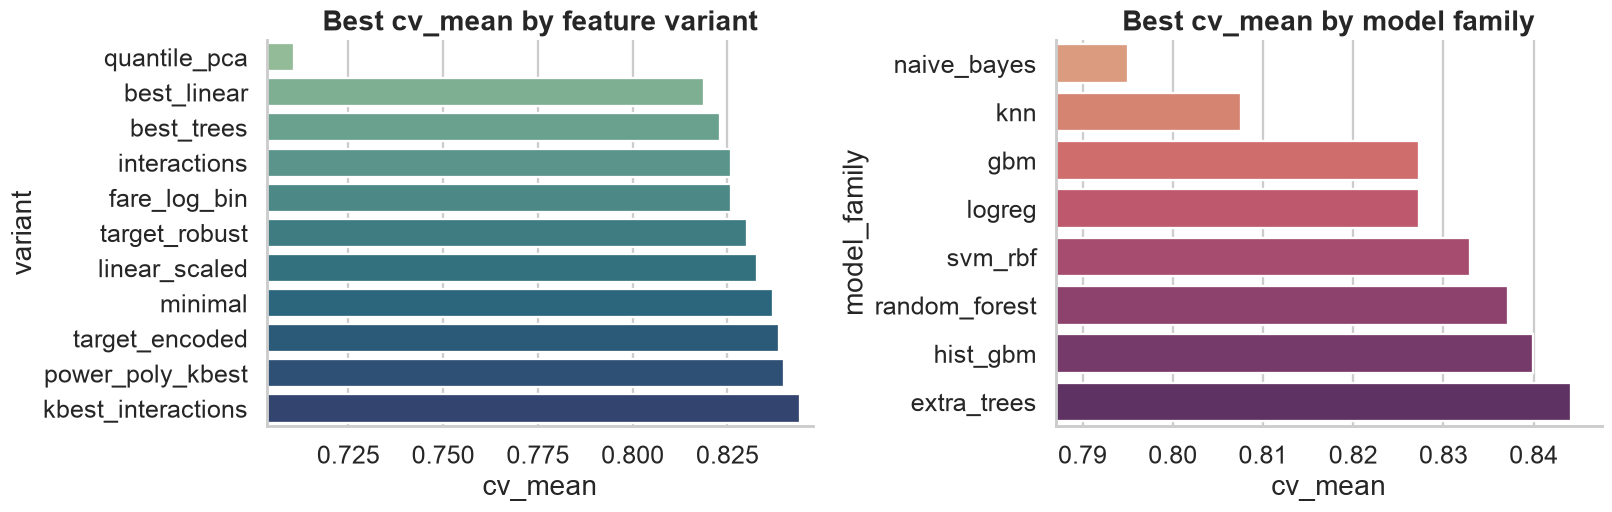

In [7]:
# cv_mean by dataset variant and by model family
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
if "variant" in board.columns:
    v = board.groupby("variant")["cv_mean"].max().sort_values()
    sns.barplot(x=v.values, y=v.index, ax=axes[0], hue=v.index, legend=False, palette="crest")
    axes[0].set_title("Best cv_mean by feature variant"); axes[0].set_xlabel("cv_mean")
    axes[0].set_xlim(v.min()*0.99, v.max()*1.004)
if "model_family" in board.columns:
    m = board.groupby("model_family")["cv_mean"].max().sort_values()
    sns.barplot(x=m.values, y=m.index, ax=axes[1], hue=m.index, legend=False, palette="flare")
    axes[1].set_title("Best cv_mean by model family"); axes[1].set_xlabel("cv_mean")
    axes[1].set_xlim(m.min()*0.99, m.max()*1.004)
sns.despine(); plt.tight_layout(); plt.show()

## 3 · What worked and what didn't

In [8]:
kpath = RUN / "knowledge.md"
if kpath.exists():
    from IPython.display import Markdown, display
    display(Markdown(kpath.read_text()))
else:
    print("knowledge.md not found (single-loop run writes it on loops 2+).")

knowledge.md not found (single-loop run writes it on loops 2+).


## 4 · How the champion reads the data

Model-agnostic **permutation importance** on the untouched holdout: each raw input
feature is shuffled and the drop in the competition metric is measured. Larger drop =
the champion relies on it more. This works for single models, ensembles, and stacks
alike because it treats the whole champion pipeline as a black box.

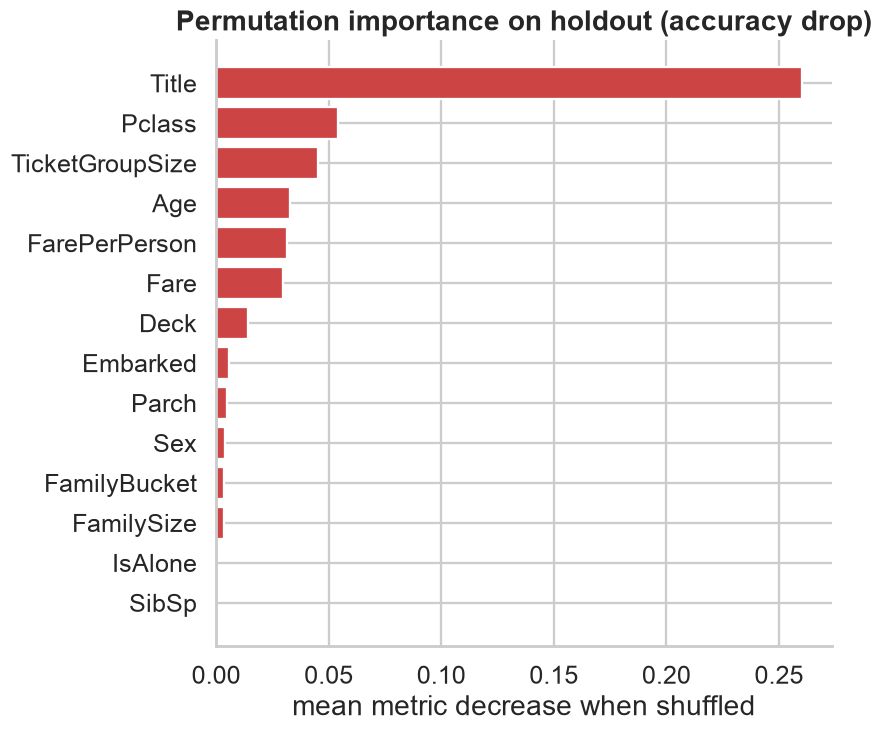

,importance
Title,0.260335
Pclass,0.054190
TicketGroupSize,0.045251
Age,0.032961
FarePerPerson,0.031285
Fare,0.029609
Deck,0.013966
Embarked,0.005587
Parch,0.005028
Sex,0.003911


In [9]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import get_scorer

est = joblib.load(RUN / "champion" / "model.joblib")

# Reconstruct the same seeded, stratified holdout the pipeline used
full = pd.read_csv(TRAIN_CSV)
if ID_COL and ID_COL in full.columns:
    full = full.drop(columns=[ID_COL])
y = full[TARGET]; X = full.drop(columns=[TARGET])
strat = y if y.nunique() <= 20 else None
Xtr, Xho, ytr, yho = train_test_split(
    X, y, test_size=HOLDOUT_FRACTION, random_state=RANDOM_STATE, stratify=strat)

scorer = {"accuracy":"accuracy","roc_auc":"roc_auc","f1":"f1"}.get(str(METRIC), "accuracy")
try:
    r = permutation_importance(est, Xho, yho, n_repeats=10,
                               random_state=RANDOM_STATE, scoring=scorer)
    imp = pd.Series(r.importances_mean, index=X.columns).sort_values()
    fig, ax = plt.subplots(figsize=(8, max(3, 0.5*len(imp))))
    colors = ["#c44" if v>0 else "#bbb" for v in imp.values]
    ax.barh(imp.index, imp.values, color=colors)
    ax.set_title(f"Permutation importance on holdout ({scorer} drop)")
    ax.set_xlabel("mean metric decrease when shuffled"); ax.set_ylabel(""); ax.axvline(0, color="grey", lw=1)
    sns.despine(); plt.tight_layout(); plt.show()
    display(imp.sort_values(ascending=False).to_frame("importance"))
except Exception as e:
    print("Permutation importance unavailable:", e)

In [10]:
# If the final estimator exposes native importances/coefficients, show them too
def native_importance(estimator):
    final = estimator
    names = None
    if hasattr(estimator, "named_steps"):
        try:
            names = estimator[:-1].get_feature_names_out()
        except Exception:
            names = None
        final = list(estimator.named_steps.values())[-1]
    if hasattr(final, "feature_importances_"):
        vals = final.feature_importances_
    elif hasattr(final, "coef_"):
        vals = np.ravel(final.coef_)
    else:
        return None
    if names is None or len(names) != len(vals):
        names = [f"f{i}" for i in range(len(vals))]
    return pd.Series(vals, index=names)

ni = native_importance(est)
if ni is not None:
    top = ni.reindex(ni.abs().sort_values(ascending=False).index).head(20)[::-1]
    fig, ax = plt.subplots(figsize=(8, max(3, 0.45*len(top))))
    sns.barplot(x=top.values, y=top.index, ax=ax, hue=top.index, legend=False, palette="crest")
    ax.set_title("Champion native importance / coefficients (top 20)")
    ax.axvline(0, color="grey", lw=1); sns.despine(); plt.tight_layout(); plt.show()
else:
    print("Champion is an ensemble/stack — see permutation importance above.")

Champion is an ensemble/stack — see permutation importance above.


## 5 · Holdout finalist round — the CV-overfit check

Every finalist was scored on data no loop, Optuna trial, or ensemble ever saw. When CV
rank and holdout rank disagree, the holdout wins — that's the tiebreak that reflects
leaderboard reality.

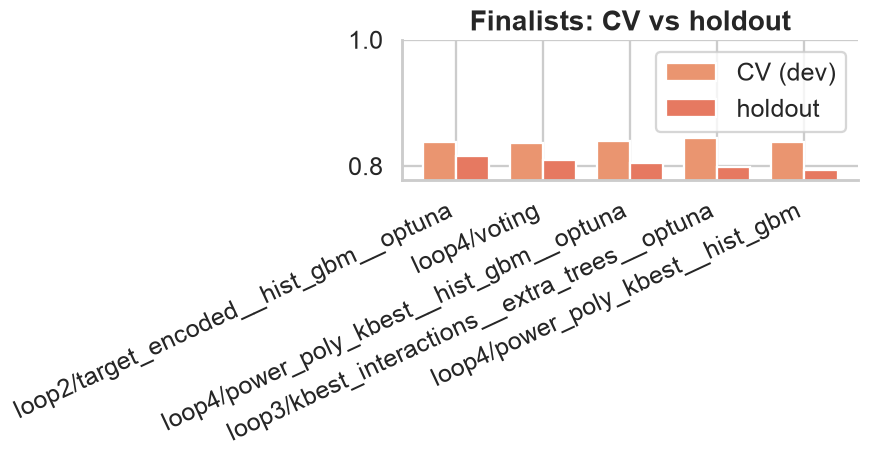

,candidate,cv_mean,holdout
0,loop2/target_encoded__hist_gbm__optuna,0.838521,0.81564
1,loop4/voting,0.837112,0.81006
2,loop4/power_poly_kbest__hist_gbm__optuna,0.839939,0.80447
3,loop3/kbest_interactions__extra_trees__optuna,0.844145,0.79888
4,loop4/power_poly_kbest__hist_gbm,0.838550,0.79330


In [11]:
fin = pd.DataFrame(champ.get("finalists", []))
if not fin.empty:
    label_col = next((c for c in ["candidate","kind","loop"] if c in fin.columns), None)
    cols = [c for c in [label_col,"cv_mean","holdout"] if c and c in fin.columns]
    fin = fin[cols].copy()
    labels = fin[label_col].astype(str) if label_col else fin.index.astype(str)
    if {"cv_mean","holdout"}.issubset(fin.columns):
        fig, ax = plt.subplots(figsize=(8, 4.5))
        idx = np.arange(len(fin)); w = 0.38
        ax.bar(idx-w/2, fin["cv_mean"], w, label="CV (dev)")
        ax.bar(idx+w/2, fin["holdout"], w, label="holdout")
        ax.set_xticks(idx); ax.set_xticklabels(labels, rotation=25, ha="right")
        lo = min(fin["cv_mean"].min(), fin["holdout"].min())
        ax.set_ylim(lo*0.98, 1.0); ax.set_title("Finalists: CV vs holdout"); ax.legend()
        sns.despine(); plt.tight_layout(); plt.show()
    display(fin.reset_index(drop=True))
else:
    print("No finalist records.")

## 6 · Reproduce & submit

```bash
cd ..
S=.claude/skills/kaggle-ml-loop/scripts
python $S/eda.py            --config config.yaml
# loops 1..N: FE recipes -> make_datasets -> train_baselines -> optimize -> ensemble
python $S/train_baselines.py --config config.yaml --loop <N>
python $S/optimize.py        --config config.yaml --loop <N>
python $S/ensemble.py        --config config.yaml --loop <N>
python $S/select_champion.py --config config.yaml
python $S/build_notebooks.py --config config.yaml --which both

# submit the champion and log the public score
cp kaggle_run/champion/submission.csv submissions/submission.csv
python src/submit.py "kaggle-ml-loop champion: titanic 20260713-0916"
```
*Generated 20260713-0916 · `kaggle-ml-loop`.*